# pSprout Introduction

This notebook introduces pSprout's core workflow: start with support molecules, apply a selected modification library, and inspect the resulting provenance-aware molecular graph.

> **Under development:** pSprout is an early-stage research tool. Generated structures are computational candidates; independently validate chemical feasibility, stability, and synthetic accessibility.

## The model

A `Space` stores canonical SMILES as graph nodes. Directed edges record the modification that produced a product. Support molecules are the starting points from which an agent expands the graph.

In [1]:
from psprout import ExhaustiveExpansionAgent, GraphStyle, Space
from psprout.modifications import ModificationLibrary

library = ModificationLibrary.load("simple")
space = Space(support_molecules=["c1ccccc1", "CO"])

print(f"Found {len(library)} modifications in library")
print(f"Starting molecules: {space.list_smiles()}")

Found 4 modifications in library
Starting molecules: ['c1ccccc1', 'CO']


## Grow a small space

`ExhaustiveExpansionAgent` retains every valid, unique proposal. Keep the iteration count low while learning: the number of candidates can grow rapidly with each additional modification and iteration.

In [2]:
modifications = [library.AddHydroxyl, library.AddFormyl, library.AddAmino]
agent = ExhaustiveExpansionAgent(space, modifications)

# for state in agent.run(max_iterations=2):
#     print( f"Iteration {state.iteration}: "
#         f"frontier={len(state.frontier)}, visited={len(state.visited)}"
#     )

for state in agent.run(max_iterations=2):
    print(f"Iteration {state.iteration}: frontier={len(state.frontier)}, visited={len(state.visited)}")
# assert len(space.get_graph()) >= 2
print(f"Space now contains {len(space.list_smiles())} molecules")

Iteration 1: frontier=9, visited=11
Iteration 2: frontier=57, visited=68
Space now contains 68 molecules


## Inspect, compare, and render

Nodes are identified by canonical SMILES and include basic RDKit descriptors. The graph retains an edge-level modification name, which makes routes to a product inspectable. `calculate_similarity()` gives the average pairwise Tanimoto similarity of the current space.

With several supports, `prune_to_support_paths()` retains only existing paths that connect them. It changes the graph in place and is currently unoptimized.

Average pairwise similarity: 0.113
Nodes: 68, edges: 66
c1ccccc1 --[Add hydroxyl group]--> Oc1ccccc1
c1ccccc1 --[Add formyl group]--> O=Cc1ccccc1
c1ccccc1 --[Add amino group]--> Nc1ccccc1
CO --[Add hydroxyl group]--> OCO
CO --[Add hydroxyl group]--> COO


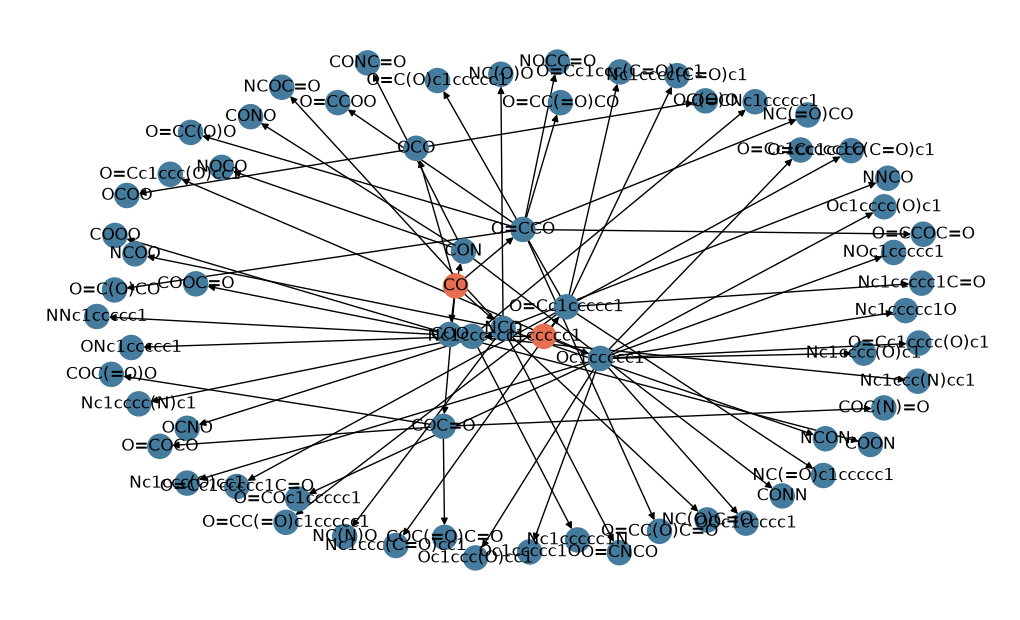

In [3]:
graph = space.get_graph()
print(f"Average pairwise similarity: {space.calculate_similarity():.3f}")
print(f"Nodes: {graph.number_of_nodes()}, edges: {graph.number_of_edges()}")

for source, target, modification in list(graph.edges(data="modification"))[:5]:
    print(f"{source} --[{modification}]--> {target}")

space.view(style=GraphStyle.mellow(), layout="spring").to_matplotlib(figsize=(10, 6))

# Next: use RandomWalkAgent or BeamSearchAgent to constrain larger explorations.
# For interactive output, call space.view().to_html("graph.html").